# C-MAPSS EDA — `eda_v1`

**Dataset:** NASA Commercial Modular Aero-Propulsion System Simulation (C-MAPSS) Turbofan Engine Degradation Simulation Data Set
**Course project:** 24-788 Introduction to Deep Learning (Spring 2026), 2-person team
**Plan:** LSTM baseline → Transformer variant → DANN (gradient reversal) for FD001→FD002 domain adaptation

This notebook is the first pass before any modeling. It answers:

1. What does the data physically look like? (schema, dtypes, missingness, structure)
2. How do the four subsets differ? (regimes, fault modes, trajectory lengths)
3. Which sensors carry signal and which are dead weight? (constant / near-constant detection)
4. How many operating conditions actually exist in FD002/FD004? (clustering on settings)
5. Do sensors visibly degrade as RUL → 0? (the modelability check)
6. How big is the FD001 → FD002 distribution shift? (the DANN motivation figure)
7. Are train and test from the same distribution? (sanity check)
8. What concrete modeling decisions does this analysis lock in? (window size, RUL clipping, sensor selection, normalization scheme)

> **Setup assumption:** the C-MAPSS zip has been extracted next to this notebook into a folder called `CMAPSSData/`, so files like `train_FD001.txt`, `test_FD001.txt`, `RUL_FD001.txt` are at `CMAPSSData/train_FD001.txt`, etc. If you keep the zip somewhere else, just edit `DATA_DIR` in the next cell.


## 1 · Setup

In [1]:
# Standard scientific Python stack — nothing exotic.
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

# Where the C-MAPSS files live. Adjust if your layout differs.
DATA_DIR = Path("CMAPSSData")
assert DATA_DIR.exists(), (
    f"Could not find {DATA_DIR.resolve()}. "
    "Extract CMAPSSData.zip next to this notebook (or edit DATA_DIR)."
)

print("Files found in DATA_DIR:")
for p in sorted(DATA_DIR.iterdir()):
    print(f"  {p.name:<30}  {p.stat().st_size/1e6:6.2f} MB")


Files found in DATA_DIR:
  Damage Propagation Modeling.pdf    0.43 MB
  RUL_FD001.txt                     0.00 MB
  RUL_FD002.txt                     0.00 MB
  RUL_FD003.txt                     0.00 MB
  RUL_FD004.txt                     0.00 MB
  readme.txt                        0.00 MB
  test_FD001.txt                    2.23 MB
  test_FD002.txt                    5.73 MB
  test_FD003.txt                    2.83 MB
  test_FD004.txt                    6.96 MB
  train_FD001.txt                   3.52 MB
  train_FD002.txt                   9.08 MB
  train_FD003.txt                   4.21 MB
  train_FD004.txt                  10.35 MB


## 2 · Schema and loading

The C-MAPSS files are space-delimited with 26 columns and **no header row**.
The official readme defines the columns as:

- `unit` — engine ID (1-indexed within each subset)
- `cycle` — operational cycle within the engine's trajectory (1-indexed)
- `setting_1`, `setting_2`, `setting_3` — operating conditions (altitude, Mach, TRA-equivalent)
- `s_1` … `s_21` — 21 sensor measurements (temperatures, pressures, fan/core speeds, etc.)

Each row is one cycle of one engine. Trajectories run **until failure** in the train sets and are **truncated before failure** in the test sets, with the true remaining cycles given in the matching `RUL_FDxxx.txt` file.

There is also some trailing whitespace in the raw files (so a naive split would create phantom empty columns). We use `sep=r"\s+"` (one-or-more whitespace) to handle this cleanly.


In [2]:
COLS = (
    ["unit", "cycle", "setting_1", "setting_2", "setting_3"]
    + [f"s_{i}" for i in range(1, 22)]
)
SENSORS  = [c for c in COLS if c.startswith("s_")]
SETTINGS = ["setting_1", "setting_2", "setting_3"]

def load_train(subset):
    # Load a training file (run-to-failure trajectories).
    df = pd.read_csv(
        DATA_DIR / f"train_{subset}.txt",
        sep=r"\s+", header=None, names=COLS, engine="python",
    )
    df["subset"] = subset
    return df

def load_test(subset):
    # Load a test file (truncated trajectories).
    df = pd.read_csv(
        DATA_DIR / f"test_{subset}.txt",
        sep=r"\s+", header=None, names=COLS, engine="python",
    )
    df["subset"] = subset
    return df

def load_rul(subset):
    # Load the true RUL value at the last observed cycle for each test engine.
    s = pd.read_csv(
        DATA_DIR / f"RUL_{subset}.txt",
        sep=r"\s+", header=None, names=["RUL"], engine="python",
    )["RUL"]
    s.index = np.arange(1, len(s) + 1)
    s.index.name = "unit"
    return s

SUBSETS = ["FD001", "FD002", "FD003", "FD004"]
train = {s: load_train(s) for s in SUBSETS}
test  = {s: load_test(s)  for s in SUBSETS}
rul   = {s: load_rul(s)   for s in SUBSETS}

# Quick smoke check.
# Note: the official readme says FD004 has 248 train / 249 test engines, but the
# actual files have these swapped (249 train / 248 test). This is a well-known
# C-MAPSS quirk; we use the *empirically* correct counts here.
expected = {"FD001": (100, 100), "FD002": (260, 259), "FD003": (100, 100), "FD004": (249, 248)}
for s in SUBSETS:
    n_train_eng = train[s]["unit"].nunique()
    n_test_eng  = test[s]["unit"].nunique()
    exp_tr, exp_te = expected[s]
    flag = "OK" if (n_train_eng == exp_tr and n_test_eng == exp_te) else "MISMATCH"
    print(f"{s}: train engines={n_train_eng:>3} (expected {exp_tr}), "
          f"test engines={n_test_eng:>3} (expected {exp_te}), RUL rows={len(rul[s]):>3}  [{flag}]")


FD001: train engines=100 (expected 100), test engines=100 (expected 100), RUL rows=100  [OK]
FD002: train engines=260 (expected 260), test engines=259 (expected 259), RUL rows=259  [OK]
FD003: train engines=100 (expected 100), test engines=100 (expected 100), RUL rows=100  [OK]
FD004: train engines=249 (expected 249), test engines=248 (expected 248), RUL rows=248  [OK]


## 3 · Subset overview

The four subsets vary along two axes — **operating conditions** (1 vs 6) and **fault modes** (1 vs 2) — giving four corners of difficulty. The plan in the project leans on this: train on FD001 (easy), test domain-adapted models on FD002 (operating-condition shift only), and possibly FD003/FD004 as future work.

| Subset | Conditions | Fault modes | Train engines | Test engines |
|--------|------------|-------------|---------------|--------------|
| FD001  | 1          | 1 (HPC)     | 100           | 100          |
| FD002  | 6          | 1 (HPC)     | 260           | 259          |
| FD003  | 1          | 2 (HPC, Fan)| 100           | 100          |
| FD004  | 6          | 2 (HPC, Fan)| 248           | 249          |

Below we confirm the row counts and check basic structure: every engine should have a contiguous `cycle` sequence starting at 1.


In [3]:
rows = []
for s in SUBSETS:
    df = train[s]
    cycles_per_engine = df.groupby("unit")["cycle"].agg(["min", "max", "count"])
    starts_at_1 = (cycles_per_engine["min"] == 1).all()
    contiguous  = (cycles_per_engine["max"] == cycles_per_engine["count"]).all()
    rows.append({
        "subset":            s,
        "train_rows":        len(df),
        "test_rows":         len(test[s]),
        "train_engines":     df["unit"].nunique(),
        "median_traj_len":   int(cycles_per_engine["count"].median()),
        "min_traj_len":      int(cycles_per_engine["count"].min()),
        "max_traj_len":      int(cycles_per_engine["count"].max()),
        "all_start_at_1":    bool(starts_at_1),
        "all_contiguous":    bool(contiguous),
    })
overview = pd.DataFrame(rows).set_index("subset")
overview


,train_rows,test_rows,train_engines,median_traj_len,min_traj_len,max_traj_len,all_start_at_1,all_contiguous
subset,,,,,,,,
FD001,20631,13096,100,199,128,362,True,True
FD002,53759,33991,260,199,128,378,True,True
FD003,24720,16596,100,220,145,525,True,True
FD004,61249,41214,249,234,128,543,True,True


## 4 · Missingness, dtypes, and basic descriptive stats

C-MAPSS is a simulation, so we expect zero missing values and all-numeric columns. We confirm that explicitly — and then look at descriptive statistics so we can spot anything that's already obviously broken (e.g. a sensor that's a single constant, an integer-valued setting that's actually categorical).


In [4]:
for s in SUBSETS:
    df = train[s]
    n_missing = df.isna().sum().sum()
    print(f"{s}: missing values = {n_missing} | dtypes = {df.dtypes.value_counts().to_dict()}")


FD001: missing values = 0 | dtypes = {dtype('float64'): 22, dtype('int64'): 4, dtype('O'): 1}
FD002: missing values = 0 | dtypes = {dtype('float64'): 22, dtype('int64'): 4, dtype('O'): 1}
FD003: missing values = 0 | dtypes = {dtype('float64'): 22, dtype('int64'): 4, dtype('O'): 1}
FD004: missing values = 0 | dtypes = {dtype('float64'): 22, dtype('int64'): 4, dtype('O'): 1}


In [5]:
# Summary stats on FD001 (single-regime — cleanest view of per-sensor variability).
desc = train["FD001"][SETTINGS + SENSORS].describe().T
desc["range"] = desc["max"] - desc["min"]
desc["cv"]    = desc["std"] / desc["mean"].replace(0, np.nan)
desc[["mean", "std", "min", "max", "range", "cv"]].round(4)


,mean,std,min,max,range,cv
setting_1,-0.0000,0.0022,-0.0087,0.0087,0.0174,-246.5927
setting_2,0.0000,0.0003,-0.0006,0.0006,0.0012,124.6632
setting_3,100.0000,0.0000,100.0000,100.0000,0.0000,0.0000
s_1,518.6700,0.0000,518.6700,518.6700,0.0000,0.0000
s_2,642.6809,0.5001,641.2100,644.5300,3.3200,0.0008
s_3,1590.5231,6.1311,1571.0400,1616.9100,45.8700,0.0039
s_4,1408.9338,9.0006,1382.2500,1441.4900,59.2400,0.0064
s_5,14.6200,0.0000,14.6200,14.6200,0.0000,0.0000
s_6,21.6098,0.0014,21.6000,21.6100,0.0100,0.0001
s_7,553.3677,0.8851,549.8500,556.0600,6.2100,0.0016


## 5 · Constant and near-constant sensors

The C-MAPSS readme advertises 21 sensors but the prognostics literature has long known that several of them are flat (no degradation signal) — most consistently `s_1`, `s_5`, `s_6`, `s_10`, `s_16`, `s_18`, `s_19` on FD001. Dropping these is standard.

We won't hardcode the drop list — we'll rediscover it empirically from each subset, because what's flat on FD001 may not be flat on FD002 (where 6 operating conditions induce sensor variation that is *condition-driven*, not degradation-driven).


In [6]:
def per_engine_std(df, col):
    # Std of a column within each engine, then averaged across engines.
    # A sensor that's constant per engine — even if it has different setpoints
    # across engines — has no degradation signal and is not useful.
    return df.groupby("unit")[col].std().mean()

flatness = []
for s in SUBSETS:
    df = train[s]
    for sensor in SENSORS:
        flatness.append({
            "subset":             s,
            "sensor":             sensor,
            "global_std":         df[sensor].std(),
            "mean_within_engine_std": per_engine_std(df, sensor),
        })
flat_df = pd.DataFrame(flatness)

# Reshape: rows = sensor, cols = subset, values = within-engine std (signal proxy).
pivot = flat_df.pivot(index="sensor", columns="subset", values="mean_within_engine_std")
pivot = pivot.reindex(SENSORS)
pivot.round(5)


subset,FD001,FD002,FD003,FD004
sensor,,,,
s_1,0.00000,26.41351,0.00000,26.48001
s_2,0.46285,37.32536,0.45710,37.40179
s_3,5.78876,106.03520,6.08960,106.27158
s_4,8.11850,119.20281,8.35158,119.43345
s_5,0.00000,3.61625,0.00000,3.62862
s_6,0.00096,5.43553,0.00279,5.45282
s_7,0.78647,146.10279,2.06549,147.00578
s_8,0.05660,145.18350,0.10634,145.37430
s_9,14.18905,335.83150,15.24944,337.07660


In [7]:
# Highlight near-constant sensors per subset (within-engine std < 1e-6).
THRESH = 1e-6
flat_per_subset = {
    s: pivot.index[pivot[s] < THRESH].tolist() for s in SUBSETS
}
for s, flats in flat_per_subset.items():
    print(f"{s}: near-constant within-engine sensors → {flats}")


FD001: near-constant within-engine sensors → ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']
FD002: near-constant within-engine sensors → []
FD003: near-constant within-engine sensors → ['s_1', 's_5', 's_16', 's_18', 's_19']
FD004: near-constant within-engine sensors → []


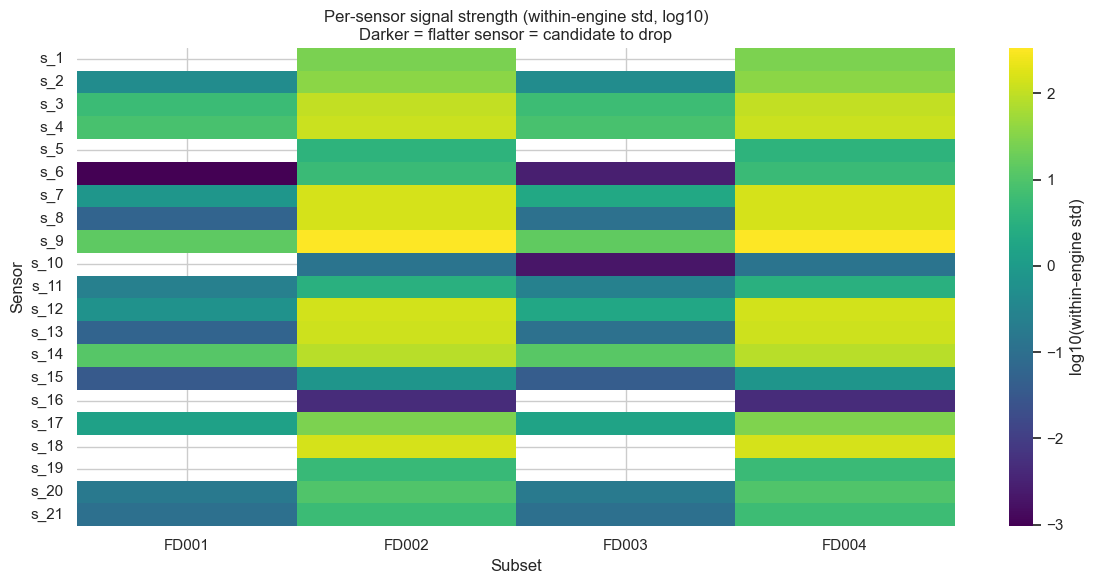

In [8]:
# Visualize sensor variability across subsets — log scale because the spread is huge.
fig, ax = plt.subplots(figsize=(12, 6))
pivot_plot = pivot.replace(0, np.nan).copy()
sns.heatmap(
    np.log10(pivot_plot + 1e-12),
    annot=False, cmap="viridis", ax=ax, cbar_kws={"label": "log10(within-engine std)"},
)
ax.set_title("Per-sensor signal strength (within-engine std, log10)\nDarker = flatter sensor = candidate to drop")
ax.set_ylabel("Sensor")
ax.set_xlabel("Subset")
plt.tight_layout(); plt.show()


## 6 · Operating-condition discovery (FD002 / FD004)

The readme says FD002 and FD004 have **six** operating conditions, but it doesn't tell us what they are. The standard PHM trick is to cluster the rows of `(setting_1, setting_2, setting_3)` and confirm we get 6 tight clusters. This matters for two reasons:

1. **Normalization.** Sensor values vary enormously across operating conditions — far more than they vary due to degradation. If we normalize globally, the regime swamps the degradation signal. Best practice on FD002/FD004 is to **normalize per operating condition** (subtract the regime's mean, divide by the regime's std).
2. **DANN motivation.** The whole point of DANN for FD001→FD002 is that FD002 has 6 regimes and FD001 has 1, so a model trained on FD001 sees a fundamentally narrower setting space.

For FD001 and FD003 (single regime) the clusters should collapse to one point — we'll confirm.


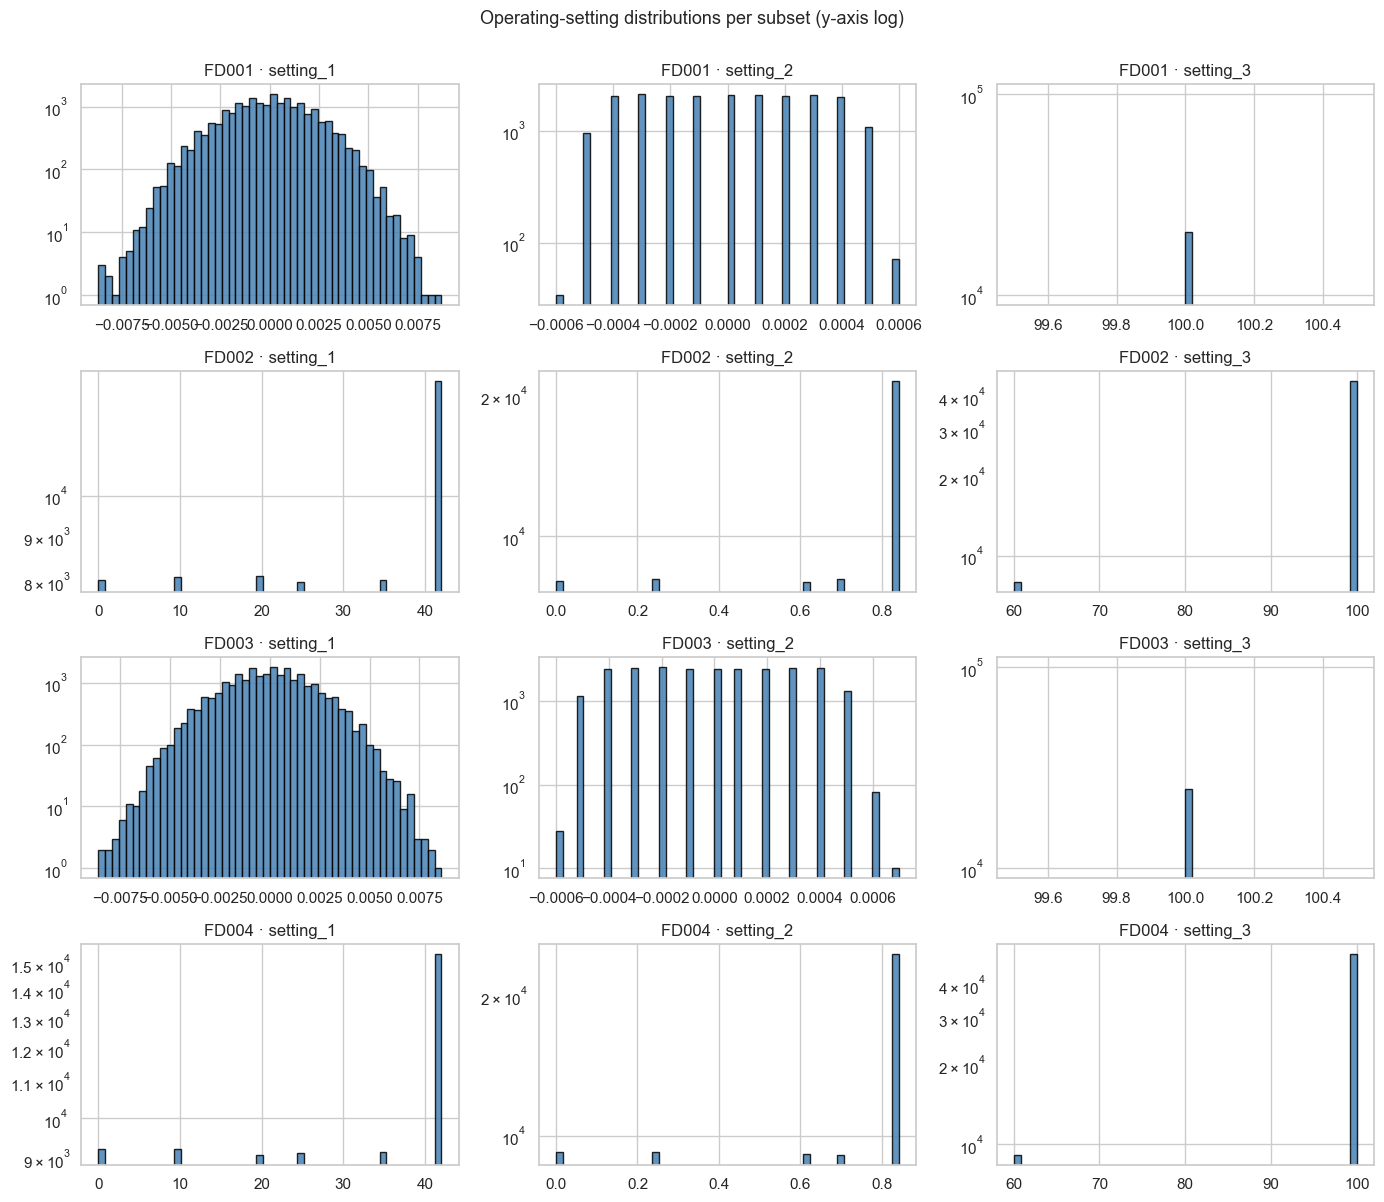

In [9]:
# Inspect raw setting distributions for each subset.
fig, axes = plt.subplots(4, 3, figsize=(14, 12), sharey=False)
for i, s in enumerate(SUBSETS):
    df = train[s]
    for j, col in enumerate(SETTINGS):
        ax = axes[i, j]
        ax.hist(df[col], bins=50, color="steelblue", edgecolor="black", alpha=0.85)
        ax.set_title(f"{s} · {col}")
        ax.set_yscale("log")
plt.suptitle("Operating-setting distributions per subset (y-axis log)", y=1.00, fontsize=13)
plt.tight_layout(); plt.show()


In [10]:
def discover_regimes(df, n_clusters=6, random_state=0):
    # Cluster (setting_1, setting_2, setting_3) and return cluster labels.
    X = df[SETTINGS].values
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state).fit(X)
    return km, km.labels_

# Fit a 6-cluster model on each subset (even single-regime ones — useful as a sanity check).
regimes = {}
for s in SUBSETS:
    km, labels = discover_regimes(train[s], n_clusters=6)
    regimes[s] = (km, labels)
    counts = pd.Series(labels).value_counts().sort_index()
    print(f"{s}: cluster sizes = {counts.tolist()},  inertia/row = {km.inertia_ / len(labels):.3e}")


/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


FD001: cluster sizes = [1812, 5107, 3586, 1622, 3988, 4516],  inertia/row = 3.589e-07
FD002: cluster sizes = [13458, 8096, 8002, 8044, 8037, 8122],  inertia/row = 7.640e-06
FD003: cluster sizes = [6327, 4368, 2009, 6215, 4173, 1628],  inertia/row = 3.632e-07
FD004: cluster sizes = [15395, 9224, 9139, 9238, 9091, 9162],  inertia/row = 7.647e-06


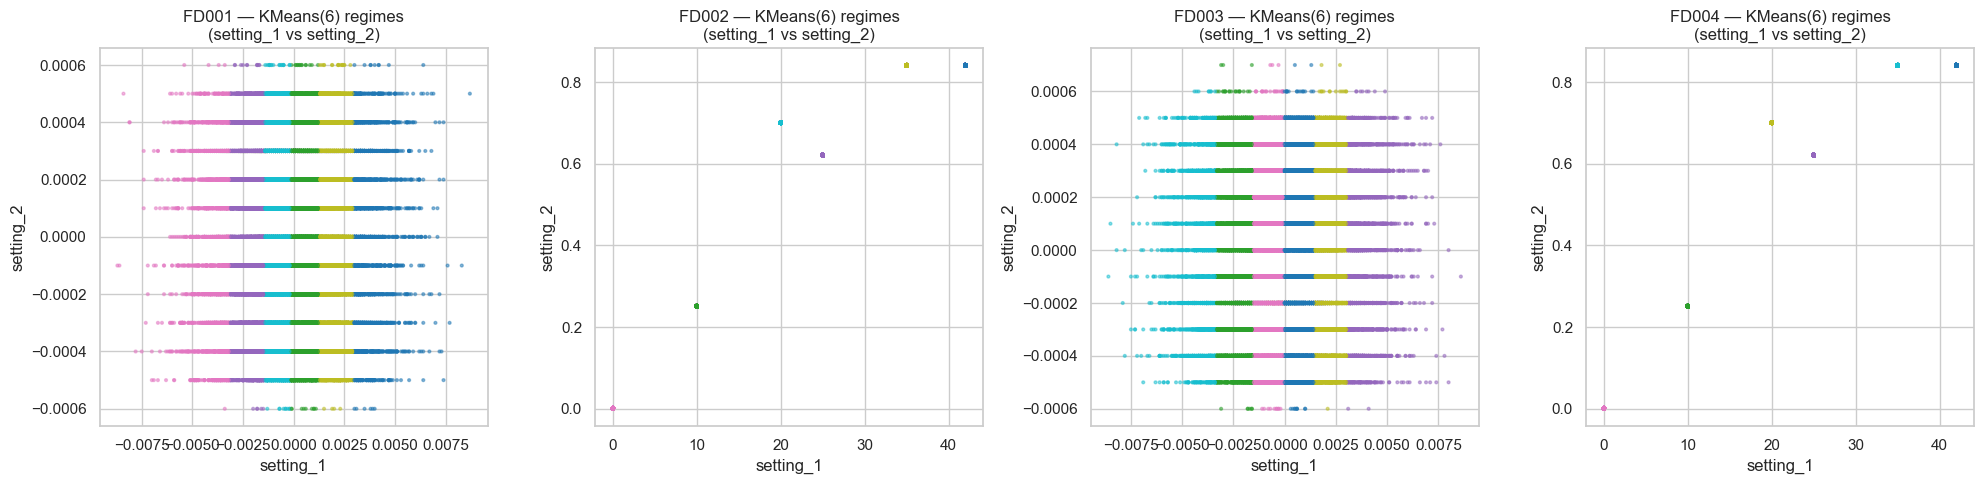

Interpretation:
  - FD001 / FD003: should look like ~1 cluster — 6 means is overkill but harmless.
  - FD002 / FD004: should resolve into 6 clean clusters → confirms readme.


In [11]:
# Visualize regime clusters in setting_1 vs setting_2 space (those are the dominant ones).
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, s in zip(axes, SUBSETS):
    df = train[s].copy()
    _, labels = regimes[s]
    df["regime"] = labels
    ax.scatter(df["setting_1"], df["setting_2"], c=df["regime"],
               cmap="tab10", s=4, alpha=0.5)
    ax.set_title(f"{s} — KMeans(6) regimes\n(setting_1 vs setting_2)")
    ax.set_xlabel("setting_1")
    ax.set_ylabel("setting_2")
plt.tight_layout(); plt.show()

print("Interpretation:")
print("  - FD001 / FD003: should look like ~1 cluster — 6 means is overkill but harmless.")
print("  - FD002 / FD004: should resolve into 6 clean clusters → confirms readme.")


## 7 · Trajectory lengths (train and test)

Two things to check:

1. **Train trajectory lengths** = lifetime distribution of engines run to failure. The shape of this histogram tells us how variable engine lifespans are, and the **minimum** sets a hard upper bound on the input window size we can use without padding.
2. **Test trajectory lengths** = how much history each test engine has *before* the truncation point. Combined with the per-engine `RUL_FDxxx.txt` value, this tells us where on the lifetime curve the test snapshots sit (early life vs near-failure).


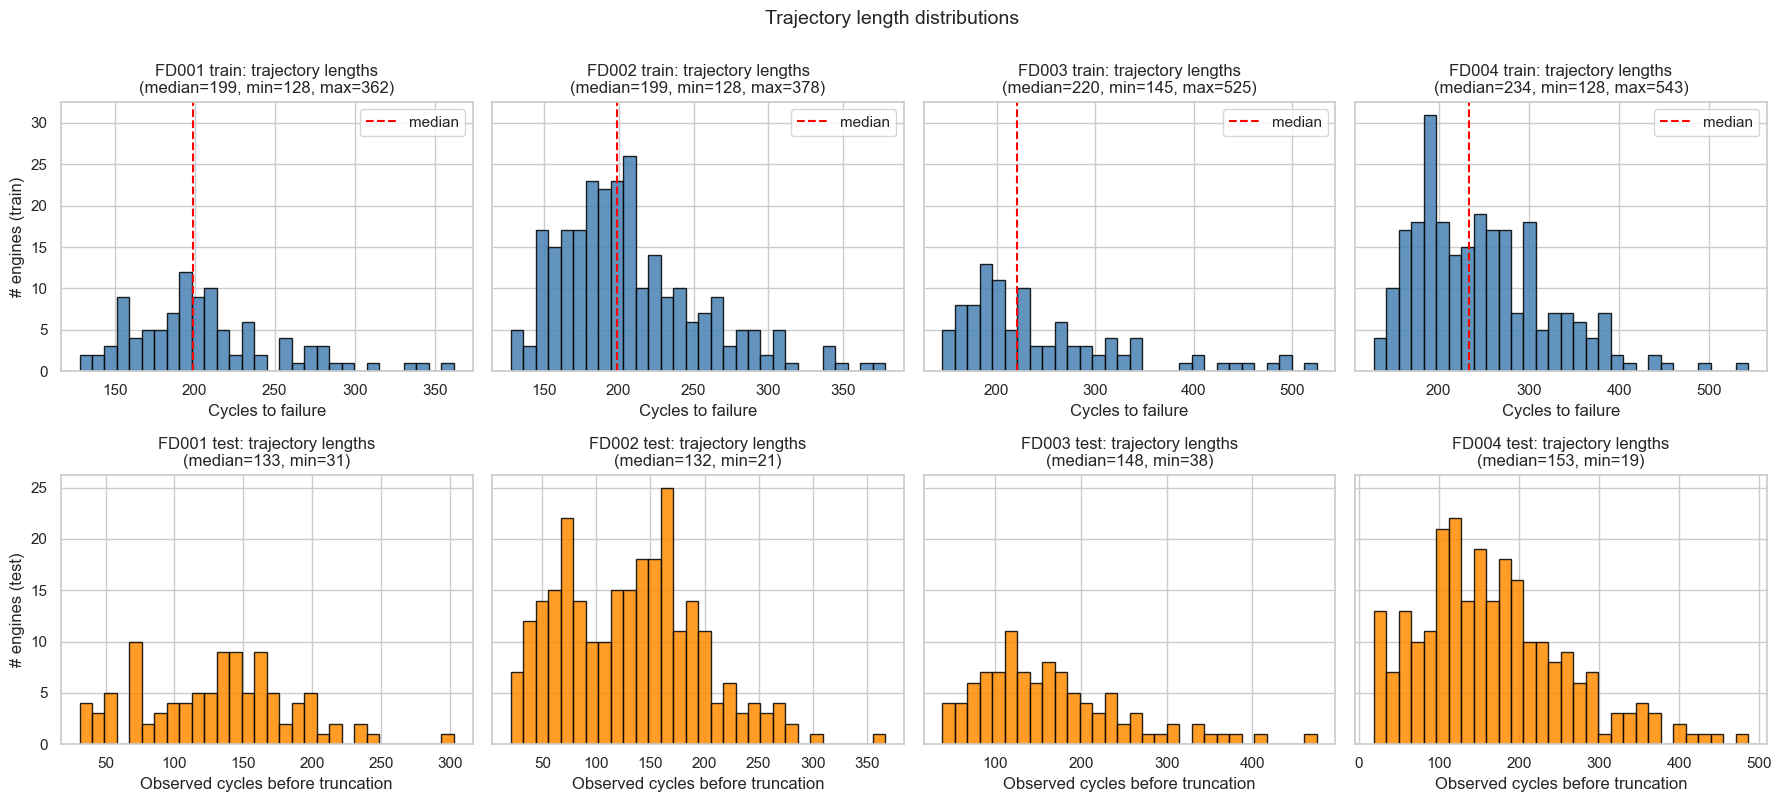

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey="row")
for j, s in enumerate(SUBSETS):
    train_lens = train[s].groupby("unit").size()
    test_lens  = test[s].groupby("unit").size()

    axes[0, j].hist(train_lens, bins=30, color="steelblue", edgecolor="black", alpha=0.85)
    axes[0, j].set_title(f"{s} train: trajectory lengths\n(median={int(train_lens.median())}, min={int(train_lens.min())}, max={int(train_lens.max())})")
    axes[0, j].set_xlabel("Cycles to failure")
    axes[0, j].axvline(train_lens.median(), color="red", linestyle="--", label="median")
    axes[0, j].legend()

    axes[1, j].hist(test_lens, bins=30, color="darkorange", edgecolor="black", alpha=0.85)
    axes[1, j].set_title(f"{s} test: trajectory lengths\n(median={int(test_lens.median())}, min={int(test_lens.min())})")
    axes[1, j].set_xlabel("Observed cycles before truncation")

axes[0, 0].set_ylabel("# engines (train)")
axes[1, 0].set_ylabel("# engines (test)")
plt.suptitle("Trajectory length distributions", y=1.00, fontsize=14)
plt.tight_layout(); plt.show()


In [13]:
# What's the shortest test trajectory in each subset? This bounds our input window length.
print("Shortest *test* trajectory per subset (bounds our sliding-window length):")
for s in SUBSETS:
    test_lens = test[s].groupby("unit").size()
    print(f"  {s}: min test trajectory = {test_lens.min()} cycles  "
          f"(percentiles 1/5/10 = {test_lens.quantile([0.01, 0.05, 0.10]).round(0).tolist()})")


Shortest *test* trajectory per subset (bounds our sliding-window length):
  FD001: min test trajectory = 31 cycles  (percentiles 1/5/10 = [34.0, 48.0, 55.0])
  FD002: min test trajectory = 21 cycles  (percentiles 1/5/10 = [24.0, 40.0, 51.0])
  FD003: min test trajectory = 38 cycles  (percentiles 1/5/10 = [41.0, 56.0, 70.0])
  FD004: min test trajectory = 19 cycles  (percentiles 1/5/10 = [20.0, 35.0, 59.0])


## 8 · Constructing RUL labels and the clipping argument

For training engines we have the *full* trajectory (run to failure), so:

$$\text{RUL}(t) = \text{max\_cycle\_for\_engine} - t$$

Early in an engine's life the degradation signal is essentially absent (sensors look like noise around their nominal values), so trying to predict an exact RUL of 250 vs 240 cycles is hopeless and only adds noise to the loss. The standard PHM-community fix is **piecewise-linear RUL clipping** at some maximum — typically 125 — which says "we don't believe RUL > 125 is meaningfully predictable, so call them all 125 and let the model focus on the degradation phase."

We'll plot the unclipped RUL distribution and overlay candidate clip values to argue for the choice.


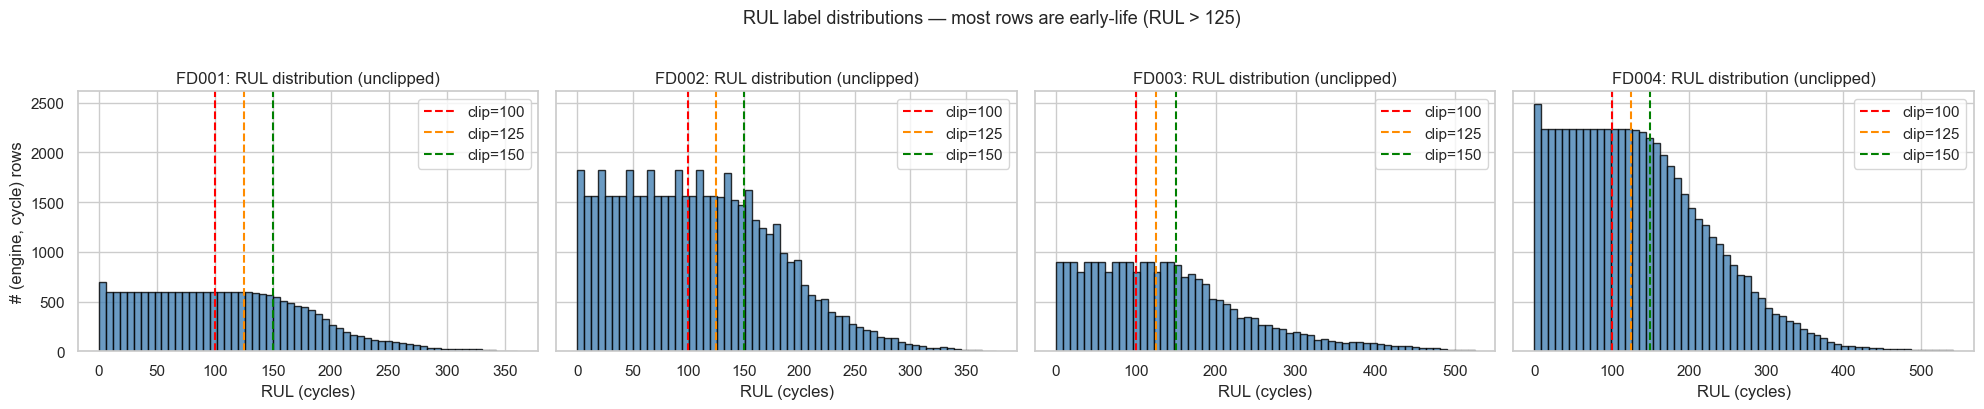

Fraction of training rows above each clip threshold (these get squashed to the clip value):
  FD001: RUL > 100 → 51.0% of rows
  FD001: RUL > 125 → 38.9% of rows
  FD001: RUL > 150 → 27.2% of rows

  FD002: RUL > 100 → 51.2% of rows
  FD002: RUL > 125 → 39.1% of rows
  FD002: RUL > 150 → 27.3% of rows

  FD003: RUL > 100 → 59.1% of rows
  FD003: RUL > 125 → 49.0% of rows
  FD003: RUL > 150 → 39.0% of rows

  FD004: RUL > 100 → 58.9% of rows
  FD004: RUL > 125 → 48.8% of rows
  FD004: RUL > 150 → 38.8% of rows



In [14]:
def add_train_rul(df):
    # Append a true-RUL column to a training dataframe.
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    df["RUL"] = max_cycle - df["cycle"]
    return df

train_rul = {s: add_train_rul(train[s]) for s in SUBSETS}

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for ax, s in zip(axes, SUBSETS):
    ax.hist(train_rul[s]["RUL"], bins=60, color="steelblue", edgecolor="black", alpha=0.8)
    for clip, color in zip([100, 125, 150], ["red", "darkorange", "green"]):
        ax.axvline(clip, linestyle="--", color=color, label=f"clip={clip}")
    ax.set_title(f"{s}: RUL distribution (unclipped)")
    ax.set_xlabel("RUL (cycles)")
    ax.legend()
axes[0].set_ylabel("# (engine, cycle) rows")
plt.suptitle("RUL label distributions — most rows are early-life (RUL > 125)", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

print("Fraction of training rows above each clip threshold (these get squashed to the clip value):")
for s in SUBSETS:
    rul_vals = train_rul[s]["RUL"]
    for clip in [100, 125, 150]:
        frac = (rul_vals > clip).mean()
        print(f"  {s}: RUL > {clip} → {frac:.1%} of rows")
    print()


**Decision so far:** clip RUL at **125** for training (the literature default and a clean compromise between "give the model some baseline regime to learn" and "don't drown out the degradation phase"). Test labels are not clipped — they're whatever the official `RUL_FDxxx.txt` files say.


## 9 · Sensor degradation trends vs RUL

If RUL is to be predictable from sensors, then sensors must *visibly* change as engines approach failure. We'll plot the average sensor reading vs RUL across many engines for FD001 (the cleanest subset) and look for monotone trends near `RUL → 0`.


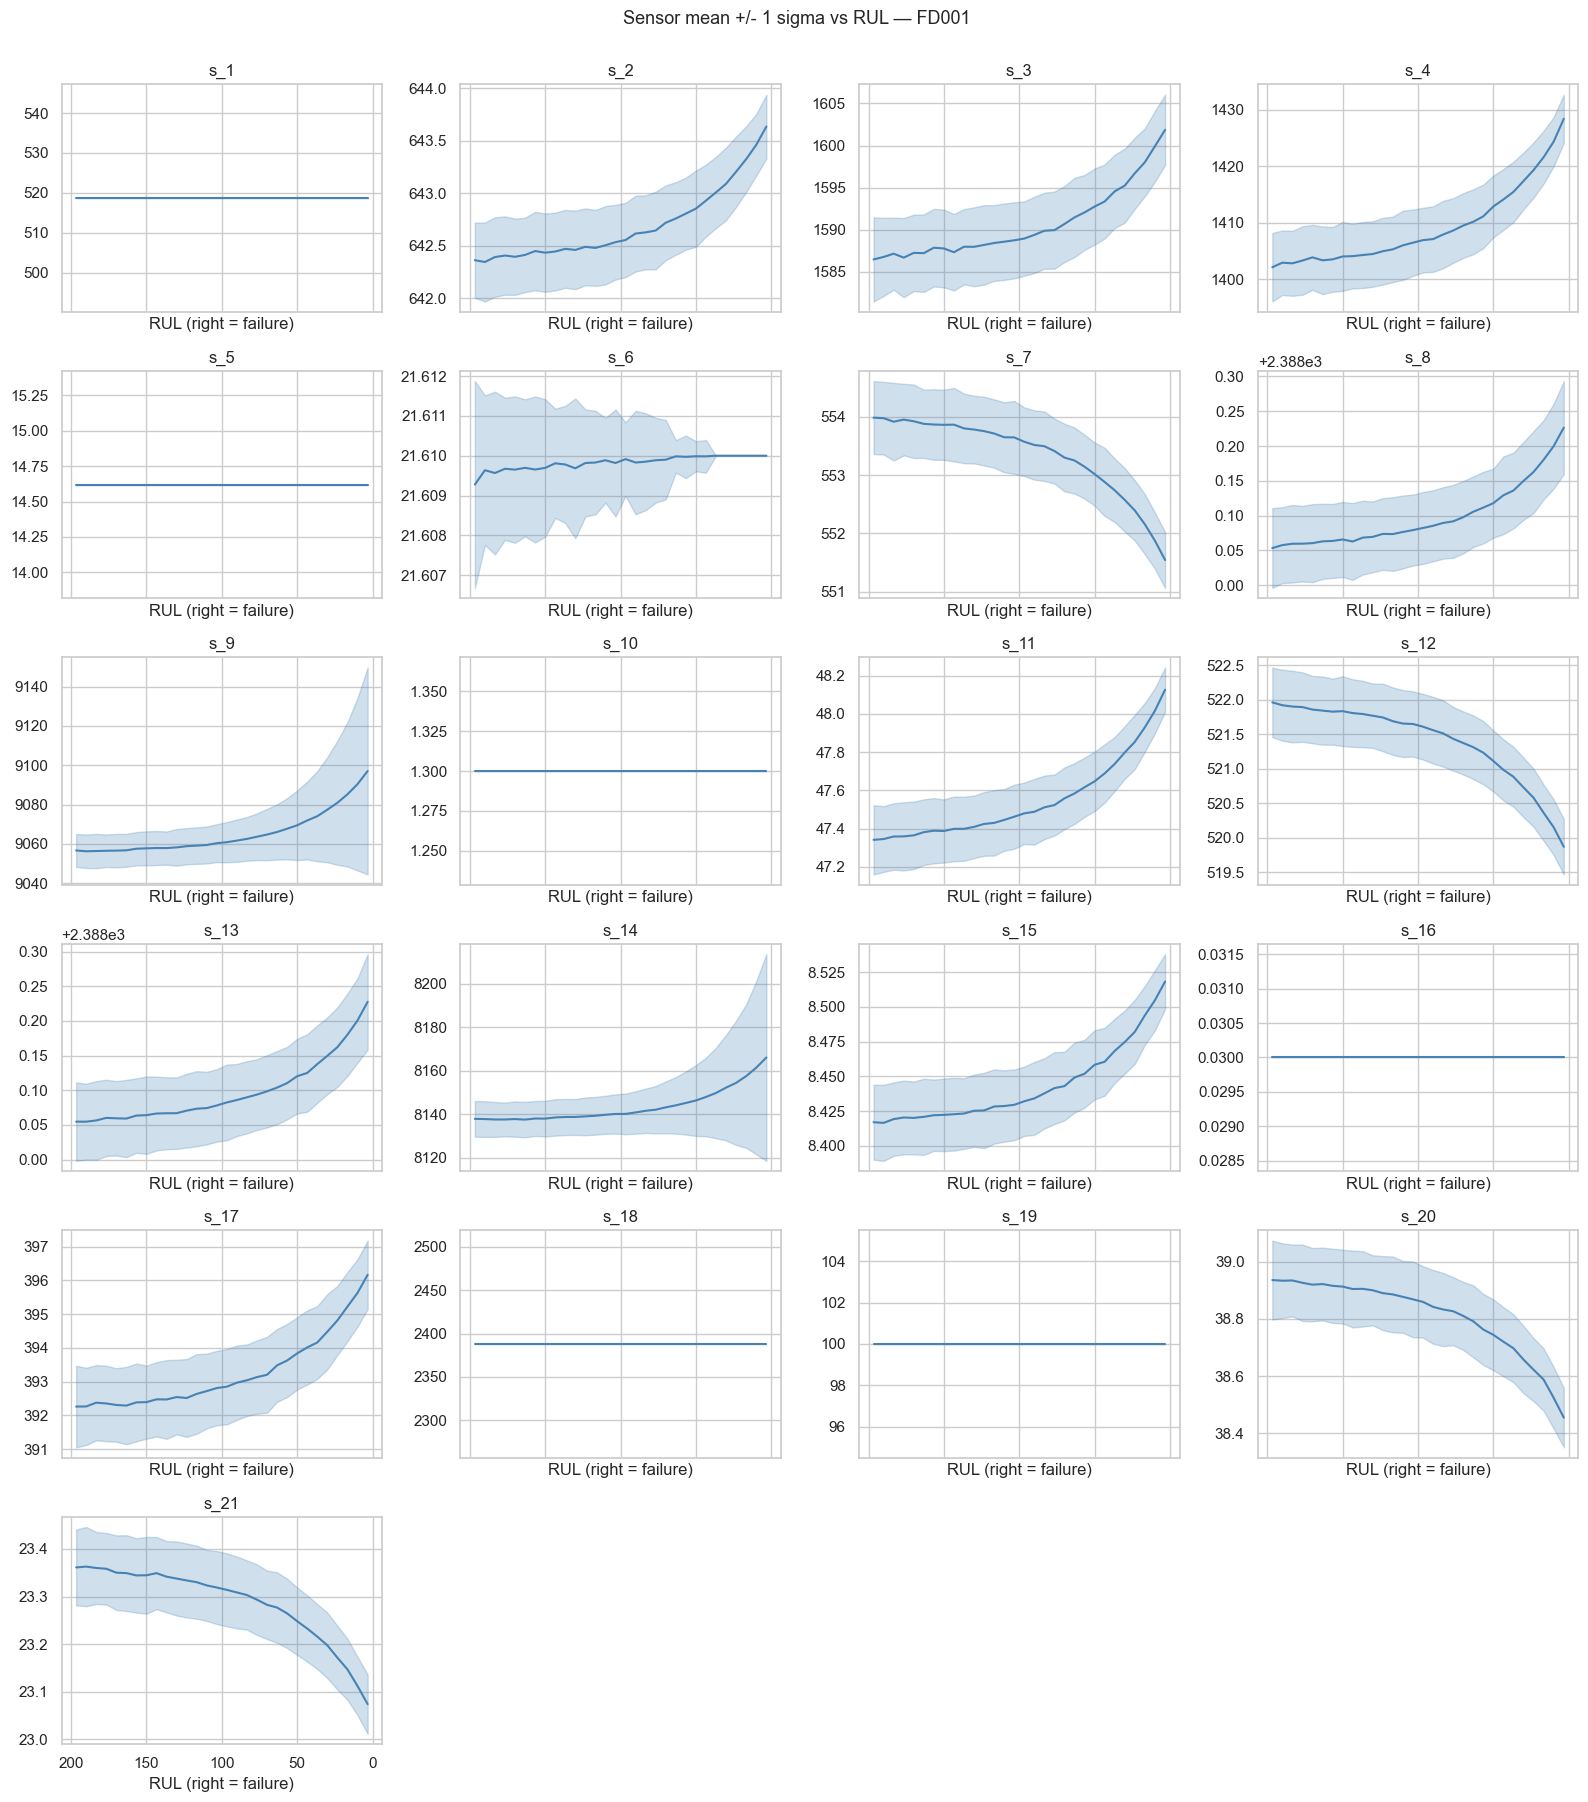

In [15]:
def plot_sensor_vs_rul(df, subset_label, sensors_to_plot, n_bins=30):
    # Group rows into RUL bins and plot mean +/- 1 sigma sensor value per bin.
    df = df[df["RUL"] <= 200].copy()
    df["rul_bin"] = pd.cut(df["RUL"], bins=n_bins)
    n = len(sensors_to_plot)
    n_cols = 4
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows), sharex=True)
    axes = np.atleast_2d(axes).flatten()
    for ax, sensor in zip(axes, sensors_to_plot):
        agg = df.groupby("rul_bin", observed=True)[sensor].agg(["mean", "std"])
        x = [interval.mid for interval in agg.index]
        ax.plot(x, agg["mean"], color="steelblue")
        ax.fill_between(x, agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                        color="steelblue", alpha=0.25)
        ax.invert_xaxis()  # left = far from failure, right = at failure
        ax.set_title(sensor)
        ax.set_xlabel("RUL (right = failure)")
    for ax in axes[len(sensors_to_plot):]:
        ax.set_visible(False)
    plt.suptitle(f"Sensor mean +/- 1 sigma vs RUL — {subset_label}", y=1.00, fontsize=13)
    plt.tight_layout(); plt.show()

# Look at all 21 sensors on FD001 — easiest to read because there's only 1 regime.
plot_sensor_vs_rul(train_rul["FD001"], "FD001", SENSORS)


Read this carefully. The sensors that show clear monotone drift toward `RUL → 0` (right-hand side) are the **informative** ones. The flat ones are the same set we flagged in §5. Common findings on FD001:

- Strong monotone trends: `s_2`, `s_3`, `s_4`, `s_7`, `s_11`, `s_12`, `s_15`, `s_17`, `s_20`, `s_21`
- Flat / not useful: `s_1`, `s_5`, `s_6`, `s_10`, `s_16`, `s_18`, `s_19`

These are exactly the 14-sensor and 7-flat-sensor splits used throughout the C-MAPSS literature.


## 10 · Cross-subset distribution shift (FD001 vs FD002) — the DANN motivation

This is the key analysis for our domain-adaptation contribution. We need to *show* that FD002 looks different from FD001 in raw sensor space — different enough that an FD001-trained model has every reason to fail on FD002.

We compare each sensor's distribution across subsets. We expect FD002 to look like a multi-modal mixture (one mode per regime) where FD001 is unimodal.


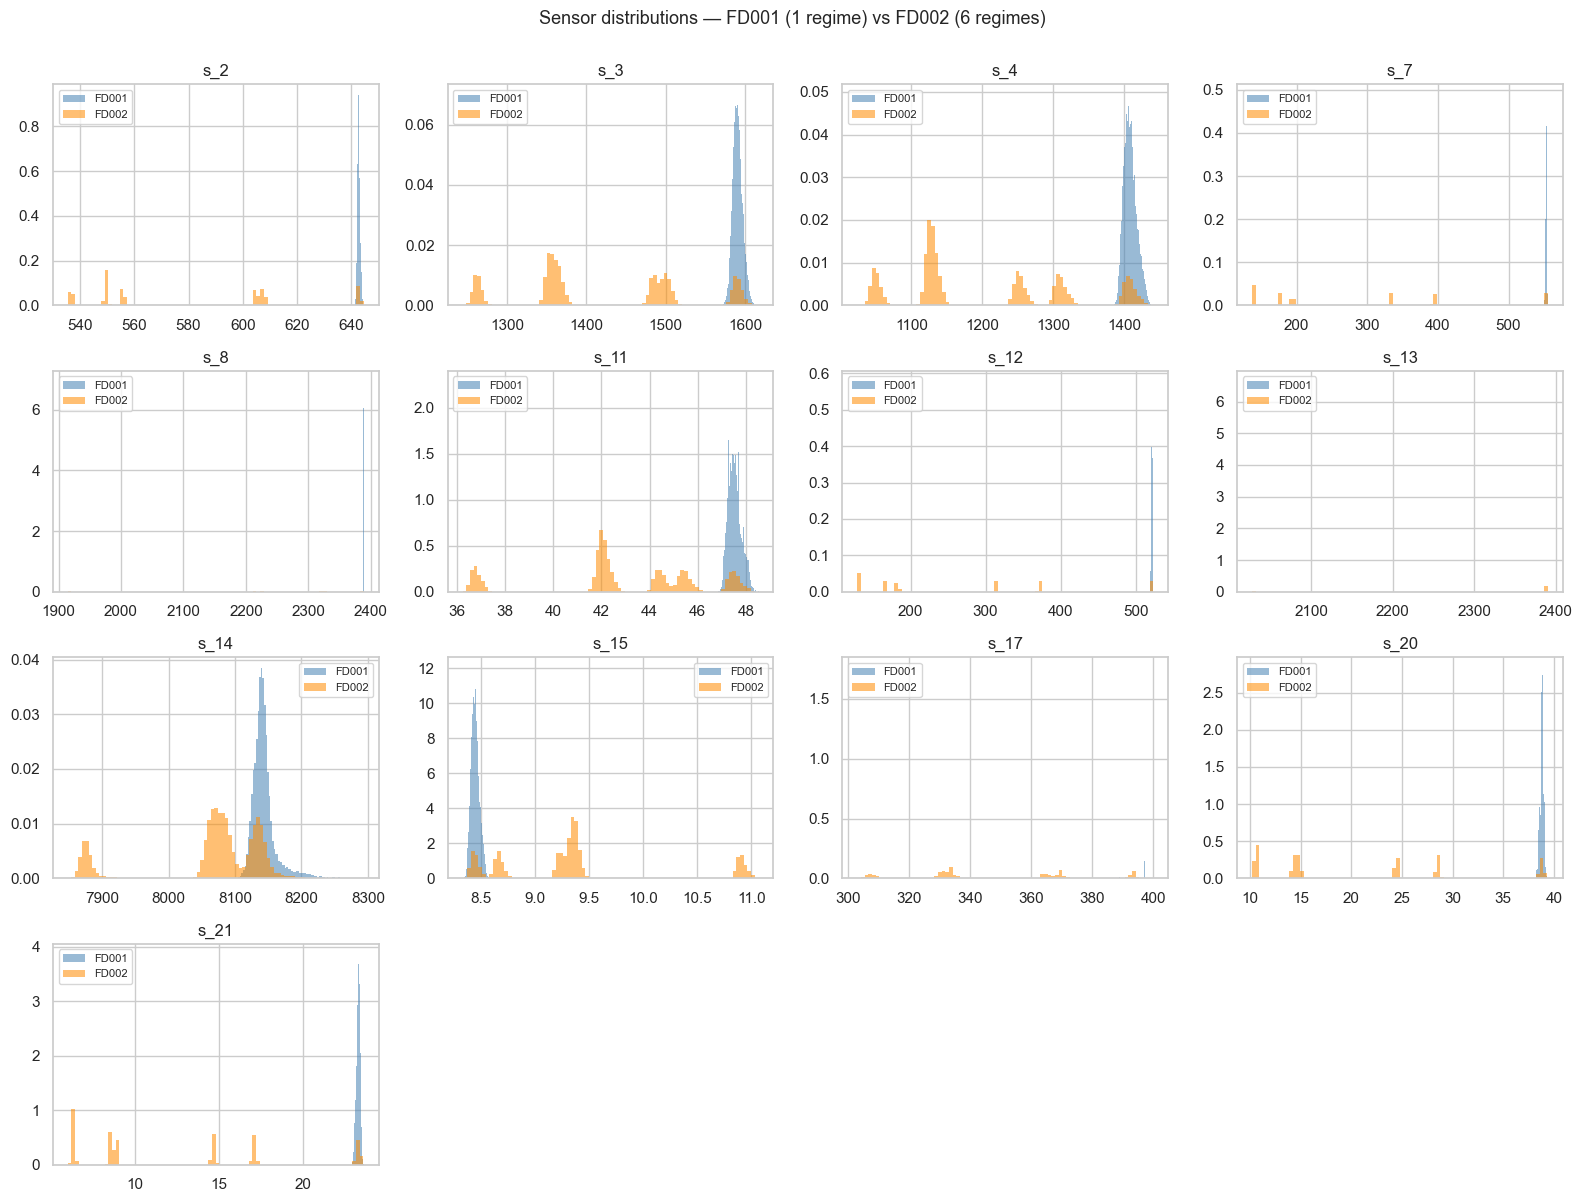

In [16]:
useful_sensors = ["s_2", "s_3", "s_4", "s_7", "s_8", "s_11", "s_12", "s_13",
                  "s_14", "s_15", "s_17", "s_20", "s_21"]
n_cols = 4
n_rows = int(np.ceil(len(useful_sensors) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()
for ax, sensor in zip(axes, useful_sensors):
    for s, color in zip(["FD001", "FD002"], ["steelblue", "darkorange"]):
        ax.hist(train[s][sensor], bins=80, alpha=0.55, color=color,
                label=s, density=True, edgecolor="none")
    ax.set_title(sensor)
    ax.legend(fontsize=8)
for ax in axes[len(useful_sensors):]:
    ax.set_visible(False)
plt.suptitle("Sensor distributions — FD001 (1 regime) vs FD002 (6 regimes)", y=1.00, fontsize=13)
plt.tight_layout(); plt.show()


Most informative sensors should be **clearly multi-modal** on FD002 and unimodal on FD001 — this is the textbook signature of an operating-regime confound. A model trained naively on FD001 has never seen the FD002 modes and will treat them as out-of-distribution. That's the whole point of bringing in DANN: force the encoder to produce features that look the same regardless of which subset (and therefore which regime mixture) a sample came from.

To make this even more concrete, we'll project to 2D with a quick PCA and color by subset.


/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


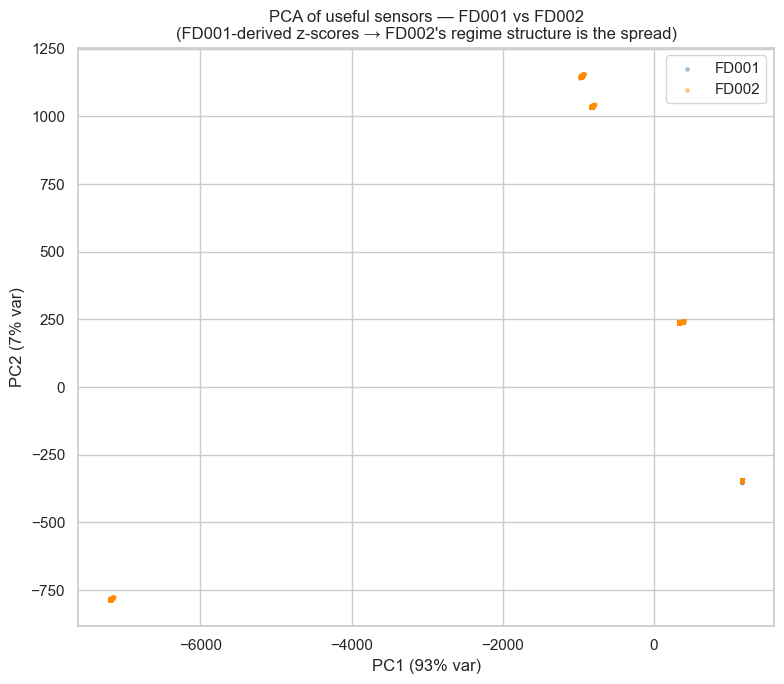

In [17]:
from sklearn.decomposition import PCA

# Sample 5000 rows from each subset for a fast scatter (PCA on the full thing is overkill).
rng = np.random.default_rng(0)
sample_size = 5000
samples = []
for s in ["FD001", "FD002"]:
    df = train[s][useful_sensors].copy()
    idx = rng.choice(len(df), size=min(sample_size, len(df)), replace=False)
    sampled = df.iloc[idx].copy()
    sampled["subset"] = s
    samples.append(sampled)
sample_df = pd.concat(samples, ignore_index=True)

# Z-score using FD001 statistics (so FD002's regime spread is visible relative to FD001).
fd001_mean = train["FD001"][useful_sensors].mean()
fd001_std  = train["FD001"][useful_sensors].std().replace(0, 1)
X = (sample_df[useful_sensors] - fd001_mean) / fd001_std

pca = PCA(n_components=2, random_state=0).fit(X)
proj = pca.transform(X)

fig, ax = plt.subplots(figsize=(8, 7))
for s, color in zip(["FD001", "FD002"], ["steelblue", "darkorange"]):
    mask = (sample_df["subset"] == s).values
    ax.scatter(proj[mask, 0], proj[mask, 1], c=color, s=6, alpha=0.4, label=s)
ax.legend()
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
ax.set_title("PCA of useful sensors — FD001 vs FD002\n(FD001-derived z-scores → FD002's regime structure is the spread)")
plt.tight_layout(); plt.show()


You should see FD002 forming several visible clouds (the regimes) while FD001 sits as a single tighter cloud. **This figure is the DANN motivation in one image.** Save this for the report's introduction.


## 11 · Sensor correlations and redundancy

Many of the 21 sensors are physically related (multiple temperatures along the same gas path, etc.) so we expect highly correlated groups. This isn't a problem for a deep model in principle, but for analysis it's worth knowing which sensors carry redundant signal.


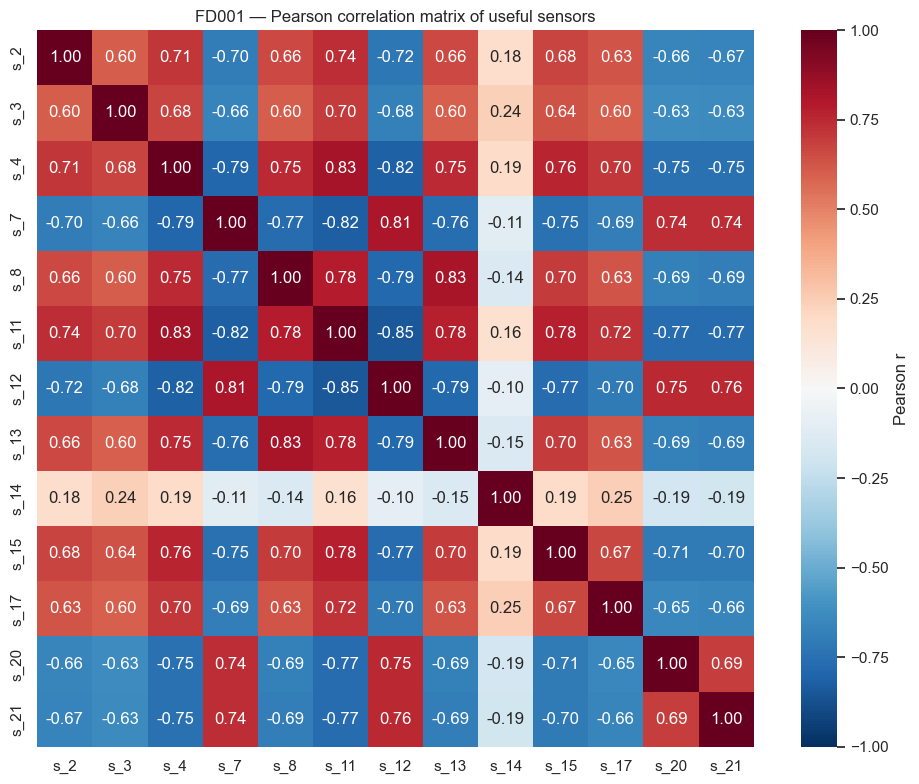

In [18]:
# Correlation matrix on FD001 — single regime keeps it interpretable.
corr = train["FD001"][useful_sensors].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("FD001 — Pearson correlation matrix of useful sensors")
plt.tight_layout(); plt.show()


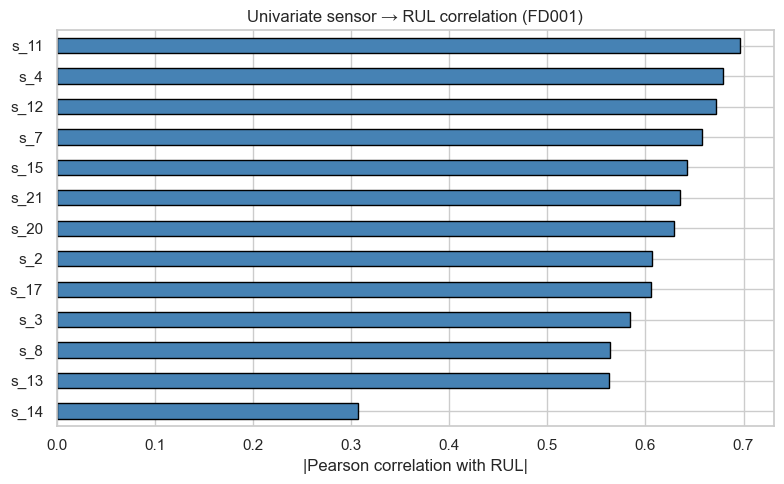

Sensors ranked by |corr(sensor, RUL)| on FD001:
s_11    0.696
s_4     0.679
s_12    0.672
s_7     0.657
s_15    0.643
s_21    0.636
s_20    0.629
s_2     0.606
s_17    0.606
s_3     0.585
s_8     0.564
s_13    0.563
s_14    0.307
Name: RUL, dtype: float64


In [19]:
# Correlation of each sensor with RUL — a crude univariate signal-strength ranking.
rul_corr = train_rul["FD001"][useful_sensors + ["RUL"]].corr()["RUL"].drop("RUL")
rul_corr_sorted = rul_corr.abs().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
rul_corr_sorted.plot.barh(ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("|Pearson correlation with RUL|")
ax.set_title("Univariate sensor → RUL correlation (FD001)")
plt.tight_layout(); plt.show()

print("Sensors ranked by |corr(sensor, RUL)| on FD001:")
print(rul_corr.abs().sort_values(ascending=False).round(3))


## 12 · Train vs test distribution check

The C-MAPSS test set is supposed to come from the same data-generating process as train (just truncated trajectories). If the marginals don't match closely, something's odd — and we want to know now, not when our model mysteriously underperforms.


In [20]:
def train_test_summary(subset, sensor_subset):
    rows = []
    for sensor in sensor_subset:
        rows.append({
            "sensor":     sensor,
            "train_mean": train[subset][sensor].mean(),
            "test_mean":  test[subset][sensor].mean(),
            "train_std":  train[subset][sensor].std(),
            "test_std":   test[subset][sensor].std(),
        })
    out = pd.DataFrame(rows)
    out["mean_diff_pct"] = ((out["test_mean"] - out["train_mean"]) / out["train_mean"].replace(0, np.nan)) * 100
    out["std_ratio"]     = out["test_std"] / out["train_std"].replace(0, np.nan)
    return out

print("FD001 — train vs test sensor moments (% diff in mean, ratio in std)")
train_test_summary("FD001", useful_sensors).round(3)


FD001 — train vs test sensor moments (% diff in mean, ratio in std)


,sensor,train_mean,test_mean,train_std,test_std,mean_diff_pct,std_ratio
0,s_2,642.681,642.475,0.500,0.401,-0.032,0.802
1,s_3,1590.523,1588.099,6.131,5.003,-0.152,0.816
2,s_4,1408.934,1404.735,9.001,6.688,-0.298,0.743
3,s_7,553.368,553.758,0.885,0.681,0.070,0.770
4,s_8,2388.097,2388.071,0.071,0.057,-0.001,0.809
5,s_11,47.541,47.416,0.267,0.196,-0.263,0.734
6,s_12,521.413,521.748,0.738,0.560,0.064,0.759
7,s_13,2388.096,2388.071,0.072,0.057,-0.001,0.792
8,s_14,8143.753,8138.948,19.076,10.189,-0.059,0.534
9,s_15,8.442,8.426,0.038,0.029,-0.193,0.773


Mean differences should be a fraction of a percent and std ratios near 1.0. If anything is dramatically off, investigate before training.


## 13 · Test-set prediction points and RUL distribution

For the test set, the model sees a trajectory truncated at some cycle, and must predict the RUL **at that final observed cycle**. The provided `RUL_FDxxx.txt` is one number per engine — the true RUL at the last observed cycle.

It's worth knowing: how much "useful information" does each test engine give us? An engine with only 30 observed cycles before truncation is a much harder prediction than one with 200 cycles of history.


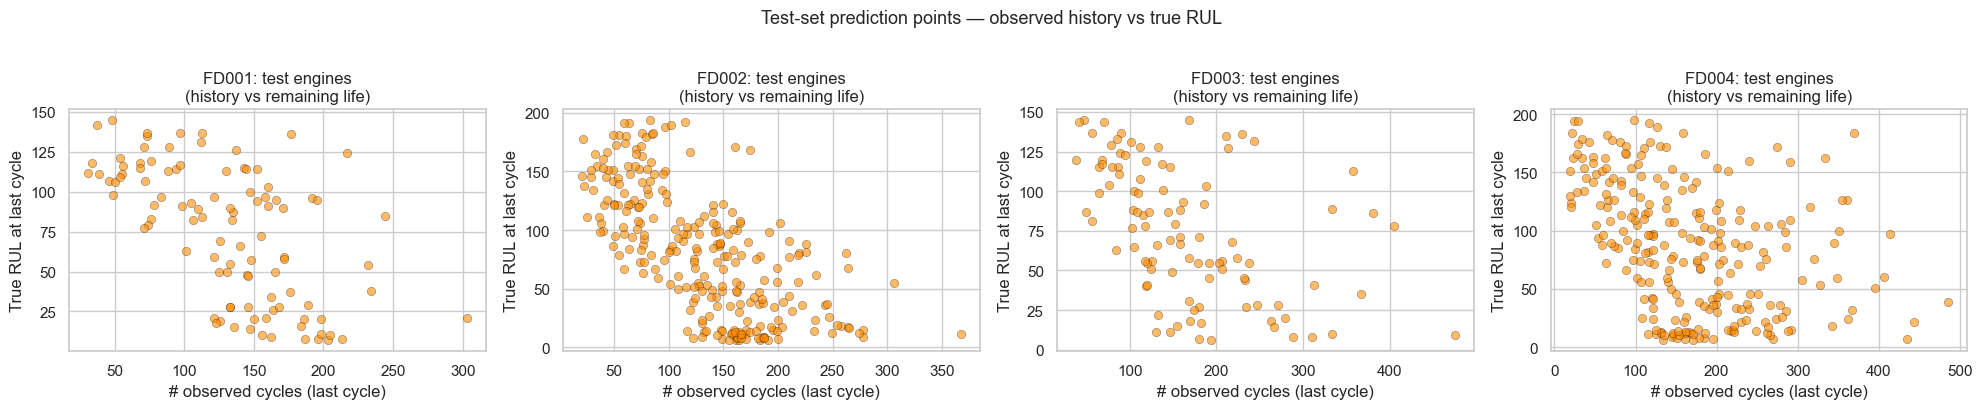

True test RUL summary stats:
  FD001: mean=75.5, median=86.0, min=7, max=145, frac > 125 = 11.0%
  FD002: mean=81.2, median=80.0, min=6, max=194, frac > 125 = 22.0%
  FD003: mean=75.3, median=77.5, min=6, max=145, frac > 125 = 15.0%
  FD004: mean=86.6, median=88.0, min=6, max=195, frac > 125 = 27.0%


In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, s in zip(axes, SUBSETS):
    last_cycles = test[s].groupby("unit")["cycle"].max()
    ax.scatter(last_cycles, rul[s], alpha=0.6, color="darkorange", edgecolor="black", linewidth=0.3)
    ax.set_xlabel("# observed cycles (last cycle)")
    ax.set_ylabel("True RUL at last cycle")
    ax.set_title(f"{s}: test engines\n(history vs remaining life)")
plt.suptitle("Test-set prediction points — observed history vs true RUL", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

print("True test RUL summary stats:")
for s in SUBSETS:
    r = rul[s]
    print(f"  {s}: mean={r.mean():.1f}, median={r.median():.1f}, "
          f"min={r.min()}, max={r.max()}, frac > 125 = {(r > 125).mean():.1%}")


Note: a non-trivial fraction of test engines have **true RUL > 125**, so if we train with RUL clipped at 125, we'll always under-predict for those. The standard fix during evaluation is to *not* clip the test labels — we just accept that the model saturates at the clip value for very-early-life engines. RMSE on those engines is dominated by the bias floor; the asymmetric score punishes late predictions specifically.


## 14 · Window-size planning

For the LSTM/Transformer baselines we'll feed a fixed-length sliding window of the most recent W cycles. Two constraints:

1. **W ≤ shortest test trajectory** — otherwise we have to pad on the front of some test engines, which is awkward and biases.
2. **W large enough to span the degradation phase** — meaning the window should cover enough cycles that some of them sit inside the regime where sensors are visibly drifting.

The shortest test trajectories (from §7) are:

- FD001: 31 cycles
- FD002: 21 cycles
- FD003: 38 cycles
- FD004: 19 cycles

So a strict no-padding policy would force W ≤ 19. Most of the literature relaxes this slightly: the canonical Zheng et al. 2017 setting is **W = 30**, which means a small fraction of test engines on FD002 / FD004 need front-padding (or have to be evaluated on whatever shorter window they have available — both options are common in published code). We'll go with **W = 30** as the working default — it matches the most-cited LSTM-on-CMAPSS paper and the padding cost is small (single-digit % of test engines) — but the next cell confirms exactly how many engines we'd need to pad for each candidate W so we can revisit if needed.


In [22]:
# Confirm: with W=30, how many test engines have at least W cycles of history?
for W in [20, 30, 40, 50]:
    print(f"\nWindow size W = {W}:")
    for s in SUBSETS:
        last_cycles = test[s].groupby("unit")["cycle"].max()
        ok = (last_cycles >= W).sum()
        total = len(last_cycles)
        print(f"  {s}: {ok}/{total} test engines have >={W} cycles ({ok/total:.0%})")



Window size W = 20:
  FD001: 100/100 test engines have >=20 cycles (100%)
  FD002: 259/259 test engines have >=20 cycles (100%)
  FD003: 100/100 test engines have >=20 cycles (100%)
  FD004: 246/248 test engines have >=20 cycles (99%)

Window size W = 30:
  FD001: 100/100 test engines have >=30 cycles (100%)
  FD002: 253/259 test engines have >=30 cycles (98%)
  FD003: 100/100 test engines have >=30 cycles (100%)
  FD004: 237/248 test engines have >=30 cycles (96%)

Window size W = 40:
  FD001: 96/100 test engines have >=40 cycles (96%)
  FD002: 247/259 test engines have >=40 cycles (95%)
  FD003: 99/100 test engines have >=40 cycles (99%)
  FD004: 232/248 test engines have >=40 cycles (94%)

Window size W = 50:
  FD001: 93/100 test engines have >=50 cycles (93%)
  FD002: 235/259 test engines have >=50 cycles (91%)
  FD003: 97/100 test engines have >=50 cycles (97%)
  FD004: 228/248 test engines have >=50 cycles (92%)


## 15 · Modeling decisions summary

Pulling everything together, here's what this EDA locks in for the modeling notebook:

**Data layout**

- 26 columns: `unit`, `cycle`, 3 settings, 21 sensors. No headers, space-delimited, trailing whitespace OK with `\s+`.
- No missing values, all numeric. Train trajectories run to failure; test trajectories truncated, with true RUL in `RUL_FDxxx.txt`.
- 4 subsets: FD001 (1 regime, 1 fault), FD002 (6 regimes, 1 fault), FD003 (1 regime, 2 faults), FD004 (6 regimes, 2 faults).

**Preprocessing**

- **Drop near-constant sensors** (per the within-engine std analysis): on FD001 these are typically `s_1, s_5, s_6, s_10, s_16, s_18, s_19`. Verify on each subset before dropping.
- **Operating-condition normalization** for FD002 / FD004: cluster `(setting_1, setting_2, setting_3)` into 6 regimes via KMeans, then z-score sensors *within each regime* using train-set statistics. For FD001 / FD003, global z-scoring is fine (single regime).
- **RUL labels**: `RUL(t) = max_cycle - t` for training engines, **clipped at 125**. Test labels stay un-clipped.

**Windowing**

- Sliding window length **W = 30** as the working default (matches Zheng et al. 2017). A small fraction of test engines on FD002 / FD004 have <30 cycles and need front-padding — the §14 cell quantifies this exactly. If padding turns out to bias evaluation, fall back to W = 20 (works for ~99% of all test engines without padding).
- Stride = 1 during training. For test we predict the RUL at the last cycle of each engine using the final 30-cycle window.

**Domain adaptation (FD001 → FD002, our DANN contribution)**

- The PCA scatter and per-sensor histograms in §10 demonstrate the FD001-vs-FD002 distribution gap — concretely it's a regime-mixture problem, not a fault-mode problem (FD002 has the same single fault as FD001). This makes FD001 → FD002 the cleanest domain-adaptation testbed.
- DANN setup: source = labeled FD001, target = unlabeled FD002 (sensor windows only), and the domain classifier predicts which subset a window came from. λ ramped 0 → 1 over training as in Ganin et al.

**Headline figures already produced for the report**

- §6 — KMeans regimes scatter (FD002 has 6 modes, FD001 has 1)
- §9 — Sensor mean ± 1σ vs RUL (proves degradation is learnable)
- §10 — FD001-vs-FD002 sensor histograms + PCA scatter (the DANN motivation in one figure)
- §13 — Test history vs true RUL (sets reader expectations on test difficulty)

These four figures alone tell the story; everything else is supporting analysis.
